<a href="https://colab.research.google.com/github/picklefarm1234/Cryptocurrency-Scam-Detection-/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

:# Analysis of cryptocurrency Scam

> A quick recap on CryptoCurrency:
> * it is a type of digital currency that exist only electronicallty.
> * Some popular cryptocurrencies are Bitcoin and ether but there exist many different cryptocurrencies.


[Crypto Scams](https://www.youtube.com/watch?v=7hq_w_L2vn4)

#Why do people use it

People can have various reasons but the main reasons are for

1. quick payments
2. Potential lower transaction fees
3. as an investment (hoping the value goes up.)

In [1]:

!gh repo clone picklefarm1234/Machine-Learning-project-

To get started with GitHub CLI, please run:  gh auth login
Alternatively, populate the GH_TOKEN environment variable with a GitHub API authentication token.


In [2]:


!gh auth login




78? Where do you use GitHub?  [Use arrows to move, type to filter]
> GitHub.com
  Other
7^C


# Importing Data ⭐

We import the data from
```
https://www.kaggle.com/datasets/zongaobian/cryptocurrency-scam-dataset/data

```

In [3]:
!pip install kagglehub

In [4]:
!pip install kagglehub[pandas-datasets]

In [5]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path1 = "uris.csv"
file_path2 = "urls.csv"

# Load the latest version
df_for_uris = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "zongaobian/cryptocurrency-scam-dataset",
  file_path1,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
df_for_urls = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "zongaobian/cryptocurrency-scam-dataset",
  file_path2,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records for uris:", df_for_uris.head(),"\n")
print("First 5 records for urls:", df_for_urls.head())

/tmp/ipykernel_7018/2346532695.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_for_uris = kagglehub.load_dataset(


100%|██████████| 3.02k/3.02k [00:00<00:00, 1.01MB/s]
/tmp/ipykernel_7018/2346532695.py:20: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_for_urls = kagglehub.load_dataset(


Using Colab cache for faster access to the 'cryptocurrency-scam-dataset' dataset.
First 5 records for uris:                                                 name  \
0                             twitter.com/cz_binance   
1                           Twitter: EthereumWallets   
2                          twitter.com/VltalkButerin   
3  twitter.com/Aurora__dao/status/960683836463075328   
4                        twitter.com/VitalikButeriin   

                                                 url  category    subcategory  \
0                     https://twitter.com/cz_binance  Scamming  Trust-Trading   
1                https://twitter.com/EthereumWallets  Phishing  MyEtherWallet   
2                  https://twitter.com/VltalkButerin  Scamming  Trust-Trading   
3  https://twitter.com/Aurora__dao/status/9606838...  Scamming  Trust-Trading   
4                 http://twitter.com/VitalikButeriin  Scamming  Trust-Trading   

                                         description  \
0           

In [6]:
#Checking out the Dataset in uris
print("for uris:\n")
print(df_for_uris.columns)
print(df_for_uris.info())
print(df_for_uris.describe(include='all'),"\n")
print("--------------------------------------------------------------------------------")
#Checking out the Dataset in urls
print("for urls:\n")
print(df_for_urls.columns)
print(df_for_urls.info())
print(df_for_urls.describe(include='all'))

for uris:

Index(['name', 'url', 'category', 'subcategory', 'description', 'addresses',
       'reporter'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   name         17 non-null     object
 1   url          17 non-null     object
 2   category     17 non-null     object
 3   subcategory  17 non-null     object
 4   description  17 non-null     object
 5   addresses    15 non-null     object
 6   reporter     17 non-null     object
dtypes: object(7)
memory usage: 1.1+ KB
None
                               name                                 url  \
count                            17                                  17   
unique                           16                                  16   
top     twitter.com/VitalikButeriin  http://twitter.com/VitalikButeriin   
freq                              2                   

## Exploring Data Tables

From https://colab.research.google.com/notebooks/data_table.ipynb#scrollTo=3jcHW3nRJpaE
i wanna have a clearer version of the dataset

In [7]:
from google.colab import data_table

data_table.enable_dataframe_formatter()

df_for_uris


,name,url,category,subcategory,description,addresses,reporter
0,twitter.com/cz_binance,https://twitter.com/cz_binance,Scamming,Trust-Trading,Trust trading 0.5ETH for 5ETH,{'ETH': ['0x08389B19ad52f0d983609ab785b3a43A0E...,CryptoScamDB
1,Twitter: EthereumWallets,https://twitter.com/EthereumWallets,Phishing,MyEtherWallet,https://bitcointalk.org/index.php?topic=168958...,NaN,CryptoScamDB
2,twitter.com/VltalkButerin,https://twitter.com/VltalkButerin,Scamming,Trust-Trading,Trust trading 0.1ETH for 2ETH,{'ETH': ['0x7bb386c33486fe345168d0af94bef03897...,CryptoScamDB
3,twitter.com/Aurora__dao/status/960683836463075328,https://twitter.com/Aurora__dao/status/9606838...,Scamming,Trust-Trading,Trust trading scam tweet,{'ETH': ['0xfa2e4bddb3899dFB0d91A70744739d9f76...,CryptoScamDB
4,twitter.com/VitalikButeriin,http://twitter.com/VitalikButeriin,Scamming,Trust-Trading,Trust trading 0.1ETH for 2ETH,{'ETH': ['0x5d82db63cf0c54d47006d416bdc7dab09e...,CryptoScamDB
5,twitter.com/VitalikBulerin,http://twitter.com/VitalikBulerin,Scamming,Trust-Trading,Trust trading 0.1ETH for 2ETH,{'ETH': ['0xA82C7c0Ef05080463E4ac55DB8b8531007...,CryptoScamDB
6,twitter.com/2017_binance,http://twitter.com/2017_binance,Scamming,Trust-Trading,Trust trading 0.1ETH for 2ETH,{'ETH': ['0xdcd2fb1c1b103c5a591e76798704cfaa27...,CryptoScamDB
7,twitter.com/VitaliikB,http://twitter.com/VitaliikB,Scamming,Trust-Trading,Trust trading 0.1ETH for 2ETH,{'ETH': ['0x5efb7d2ab258b18c8166b0c74fc4117716...,CryptoScamDB
8,twitter.com/VitallikButerin,http://twitter.com/VitallikButerin,Scamming,Trust-Trading,Trust trading 0.1ETH for 2ETH,{'ETH': ['0x414bca672494b8f078112c52ae258f9e8d...,CryptoScamDB
9,twitter.com/VitalikButeriin,http://twitter.com/VitalikButeriin,Scamming,Trust-Trading,Trust trading 0.1ETH for 2ETH,{'ETH': ['0x3dfE9F7Af8864DF0b7Cc2a20430006fd1a...,CryptoScamDB


In [8]:
from google.colab import data_table

data_table.enable_dataframe_formatter()

df_for_urls


,name,url,category,subcategory,description,addresses,reporter
0,xn--myetherwallt-leb.com,http://xn--myetherwallt-leb.com,Phishing,MyEtherWallet,Google reports site as insecure,NaN,CryptoScamDB
1,myelherwallel.com,http://myelherwallel.com,Phishing,MyEtherWallet,NaN,{'ETH': ['0xD0cC2B24980CBCCA47EF755Da88B220a82...,CryptoScamDB
2,myetherwallet.cam,http://myetherwallet.cam,Phishing,MyEtherWallet,redirecting to real site but that happened before,NaN,CryptoScamDB
3,coindash.ru,http://coindash.ru,Phishing,Coindash,someone plz check,NaN,CryptoScamDB
4,coin-wallet.info,http://coin-wallet.info,Phishing,Coindash,scam wallet,NaN,CryptoScamDB
...,...,...,...,...,...,...,...
9884,etherscan-approve.negle-universet.dk,https://etherscan-approve.negle-universet.dk,Phishing,Etherscan,Fake Etherscan site phishing for secrets with ...,NaN,CryptoScamDB
9885,coolmansuniversebabies.com,https://coolmansuniversebabies.com,Phishing,Coolmansuniverse,Fake Coolmansuniverse site phishing for funds,{'ETH': ['0x4eba1ce155f9dc95d70e5ab2a94898b4f2...,CryptoScamDB
9886,usdtpos.net,https://usdtpos.net,Scamming,Investment,Fake investment platform phishing for funds - ...,{'ETH': ['0x726f8c502b37c05cb08642f6350ee8a94e...,CryptoScamDB
9887,eth-radar.com,https://eth-radar.com,Phishing,Yearn,Fake YearnFinance site phishing for funds,{'ETH': ['0xb6af46be91b1ba4043c99f968c18871d3a...,CryptoScamDB


#Checking for duplicated
based on
```
https://note.nkmk.me/en/python-pandas-duplicated-drop-duplicates/
```


In [9]:
print(df_for_uris.duplicated())
print(df_for_urls.duplicated())

print(df_for_uris.duplicated().sum())
print(df_for_urls.duplicated().sum())

print(df_for_uris[df_for_uris.duplicated()])
print(df_for_urls[df_for_urls.duplicated()])

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
dtype: bool
0       False
1       False
2       False
3       False
4       False
        ...  
9884    False
9885    False
9886    False
9887    False
9888    False
Length: 9889, dtype: bool
0
13
Empty DataFrame
Columns: [name, url, category, subcategory, description, addresses, reporter]
Index: []
                             name                                 url  \
2215     myetherwalletconfirm.com    https://myetherwalletconfirm.com   
2801            nucleus-vision.cc           https://nucleus-vision.cc   
2822                   dock.promo                  https://dock.promo   
2972  xn--metherwallt-819eo1a.com  http://xn--metherwallt-819eo1a.com   
3538        bonus.gift-ethers.com        http://bonus.gift-ethers.com   
3705     login-myetherwallets.com     http://login-myethe

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
from google.colab import drive
drive.flush_and_unmount() # Unmount before attempting to mount again
drive.mount('/content/drive', force_remount=True)
import pandas as pd

Mounted at /content/drive


In [13]:

#SKIP THIS
# Dropping the duplicates
#df_for_uris = df_for_uris.drop_duplicates()
#df_for_urls = df_for_urls.drop_duplicates()

# Then saving these into my google drive

# uris
#df_for_uris_DB_cleaned = '/content/drive/MyDrive/Data_for_scam/df_for_uris_DB_cleaned.csv'
#df_for_uris.to_csv(df_for_uris_DB_cleaned, index=False, header = False)
#df_for_uris.columns = ["Title/name of Scam", "Web Adress/domain","Category","Subcategory","Description","Crypto wallet address","Reporter"]
#df_for_uris.to_csv(df_for_uris_DB_cleaned)
#print(f"CSV saved to: {df_for_uris_DB_cleaned}")

# urls
#df_for_urls_DB_cleaned = '/content/drive/MyDrive/Data_for_scam/df_for_urls_DB_cleaned.csv'
#df_for_urls.to_csv(df_for_urls_DB_cleaned, index=False, header=False)
#df_for_urls.columns = ["Title/name of Scam", "Web Adress/domain","Category","Subcategory","Description","Crypto wallet address","Reporter"]
#df_for_urls.to_csv(df_for_urls_DB_cleaned)
#print(f"CSV saved to: {df_for_urls_DB_cleaned}")


In [14]:
#check if it did delete
print(df_for_uris.duplicated())
print(df_for_urls.duplicated())

print(df_for_uris.duplicated().sum())
print(df_for_urls.duplicated().sum())

print(df_for_urls[df_for_urls.duplicated()])
print(df_for_uris[df_for_uris.duplicated()])

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
dtype: bool
0       False
1       False
2       False
3       False
4       False
        ...  
9884    False
9885    False
9886    False
9887    False
9888    False
Length: 9889, dtype: bool
0
13
                             name                                 url  \
2215     myetherwalletconfirm.com    https://myetherwalletconfirm.com   
2801            nucleus-vision.cc           https://nucleus-vision.cc   
2822                   dock.promo                  https://dock.promo   
2972  xn--metherwallt-819eo1a.com  http://xn--metherwallt-819eo1a.com   
3538        bonus.gift-ethers.com        http://bonus.gift-ethers.com   
3705     login-myetherwallets.com     http://login-myetherwallets.com   
3737      output.jsbin.com/jejegu     https://output.jsbin.com/jejegu   
4194           

# Want to check if the data is invalanced

> based on https://dev.to/agustin_bereciartua/building-a-fraud-detection-system-in-python-with-machine-learning-1p3n


In [15]:
#for uris
print("for uris: \n")
print(df_for_uris['category'].value_counts())
#for urls
print("======================================")
print("for urls:\n")
print(df_for_urls['category'].value_counts())

for uris: 

category
Scamming    15
Phishing     1
Fake ICO     1
Name: count, dtype: int64
for urls:

category
Phishing    5946
Scamming    3875
Malware       67
Hacked         1
Name: count, dtype: int64


# Lets visualize the dataset a bit

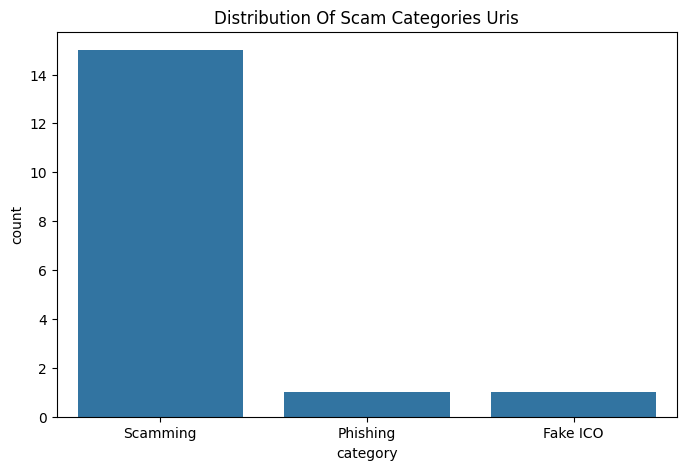

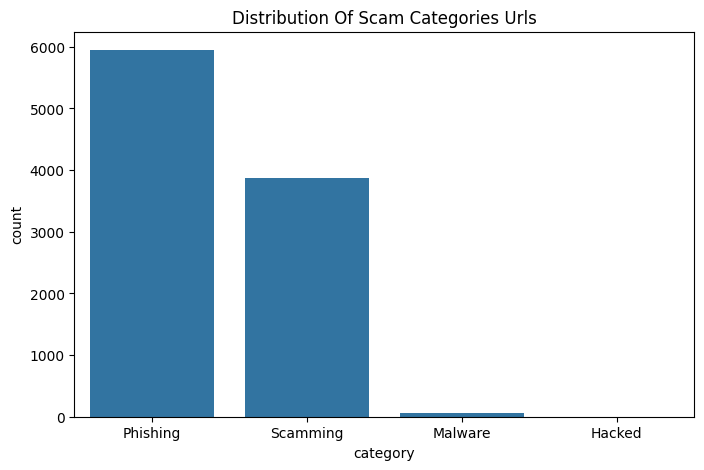

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse

# category distribution uris
plt.figure(figsize=(8,5))
sns.countplot(x='category', data=df_for_uris)
plt.title('Distribution Of Scam Categories Uris')


# category distribution urls
plt.figure(figsize=(8,5))
sns.countplot(x='category', data=df_for_urls)
plt.title('Distribution Of Scam Categories Urls')


plt.show()


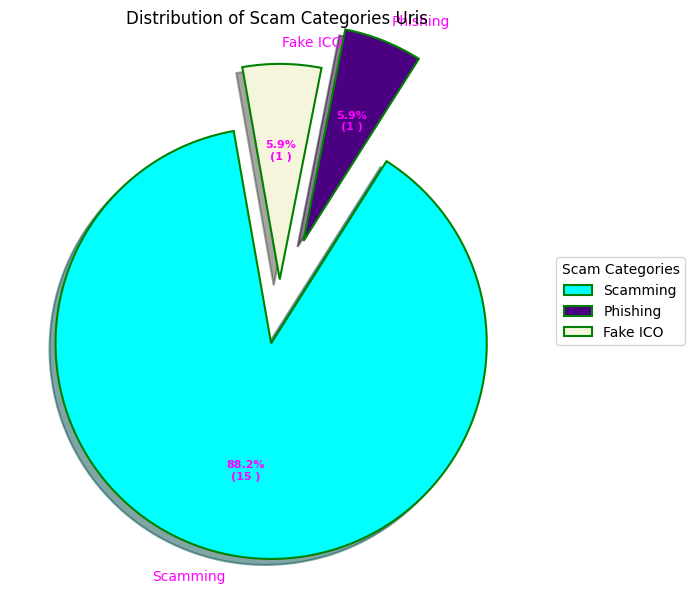

In [16]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
# Pie chart for scam categories
# https://www.geeksforgeeks.org/python/plot-a-pie-chart-in-python-using-matplotlib/

# Creating color parameters
colors = ("cyan","indigo", "beige")

# Wedge properties
wp = {'linewidth': 1.5, 'edgecolor': "green"}


# Creating autocpt arguments
def func(pct, allvalues):
    absolute = int(pct / 100. * np.sum(allvalues))
    return "{:.1f}%\n({:d} )".format(pct, absolute)

category_counts = df_for_uris['category'].value_counts()


# Creating explode data
explode = (0.2, 0.3, 0.1)


# Creating plot
fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(category_counts,
                                   labels=category_counts.index,
                                   explode=explode,
                                   autopct=lambda pct: func(pct, category_counts),
                                   startangle=100,
                                   colors=colors,
                                   wedgeprops=wp,
                                   textprops=dict(color="magenta"),
                                   shadow=True)




# Adding legend
ax.legend(wedges, category_counts.index,
          title="Scam Categories", loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")
ax.set_title("Distribution of Scam Categories Uris ")

# Show the plot
plt.show()

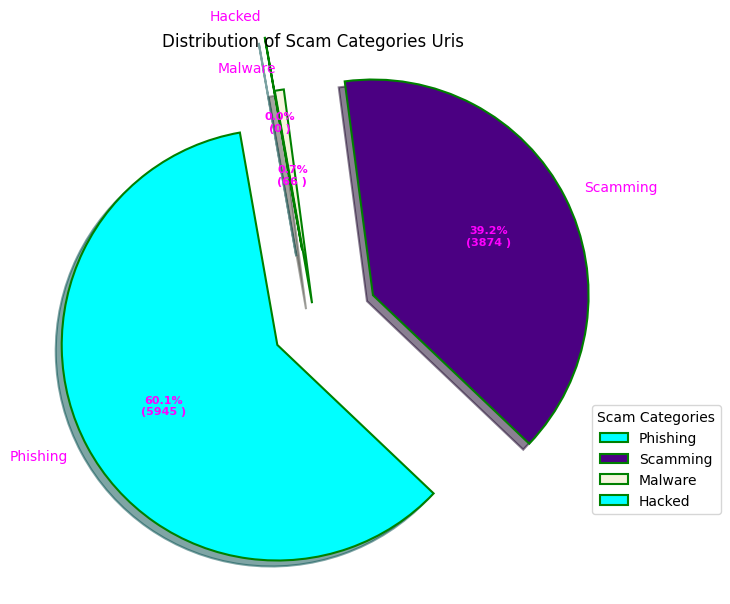

In [18]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
# Pie chart for scam categories
# https://www.geeksforgeeks.org/python/plot-a-pie-chart-in-python-using-matplotlib/

# Creating color parameters
colors = ("cyan","indigo", "beige")

# Wedge properties
wp = {'linewidth': 1.5, 'edgecolor': "green"}


# Creating autocpt arguments
def func(pct, allvalues):
    absolute = int(pct / 100. * np.sum(allvalues))
    return "{:.1f}%\n({:d} )".format(pct, absolute)

category_countsU = df_for_urls['category'].value_counts()


# Creating explode data
explode = (0.2, 0.3, 0.1, 0.35)


# Creating plot
fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(category_countsU,
                                   labels=category_countsU.index,
                                   explode=explode,
                                   autopct=lambda pct: func(pct, category_countsU),
                                   startangle=100,
                                   colors=colors,
                                   wedgeprops=wp,
                                   textprops=dict(color="magenta"),
                                   shadow=True)




# Adding legend
ax.legend(wedges, category_countsU.index,
          title="Scam Categories", loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 0.5))

plt.setp(autotexts, size=8, weight="bold")
ax.set_title("Distribution of Scam Categories Uris ")

# Show the plot
plt.show()

In [19]:
print(df_for_urls['url'].value_counts().head(10))

url
http://ethpays99.top                2
https://output.jsbin.com/jejegu     2
http://chainlink.pro                2
http://myetherwallet-sigen.space    2
https://ethgive.online              2
http://bonus.gift-ethers.com        2
http://metamaskwallets.link         2
https://myetherwalletconfirm.com    2
https://uniswapcloud.com            2
http://myetherwallet.lt             2
Name: count, dtype: int64


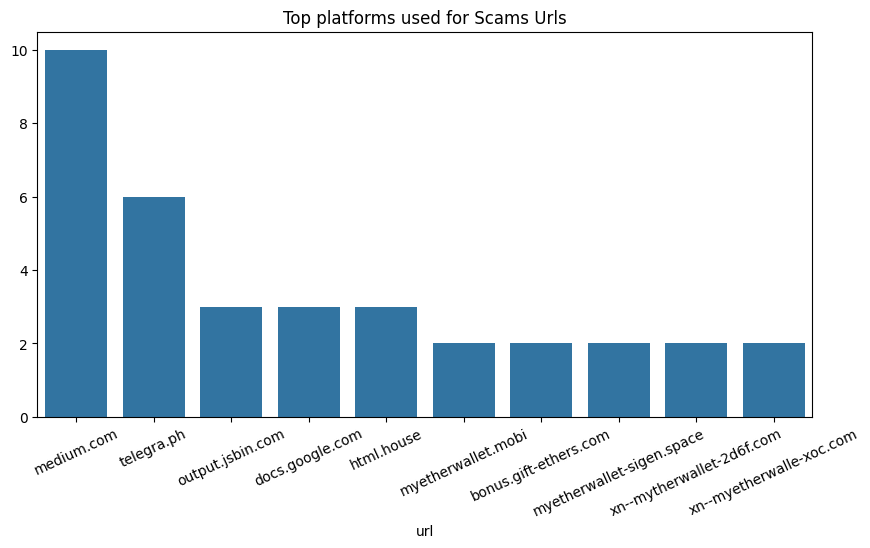

In [20]:

# want to see url
#https://datascientyst.com/extract-domain-from-url-in-pandas/
df_for_urls['url'] = df_for_urls['url'].apply(lambda x: urlparse(x)[1])

Top_urls= df_for_urls['url'].value_counts().head(10)


plt.figure(figsize=(10,5))
sns.barplot(x=Top_urls.index, y=Top_urls.values)
plt.xticks(rotation=25)
plt.title("Top platforms used for Scams Urls")



plt.show()


Text(0.5, 1.0, 'Top platforms used for Scams Uris')

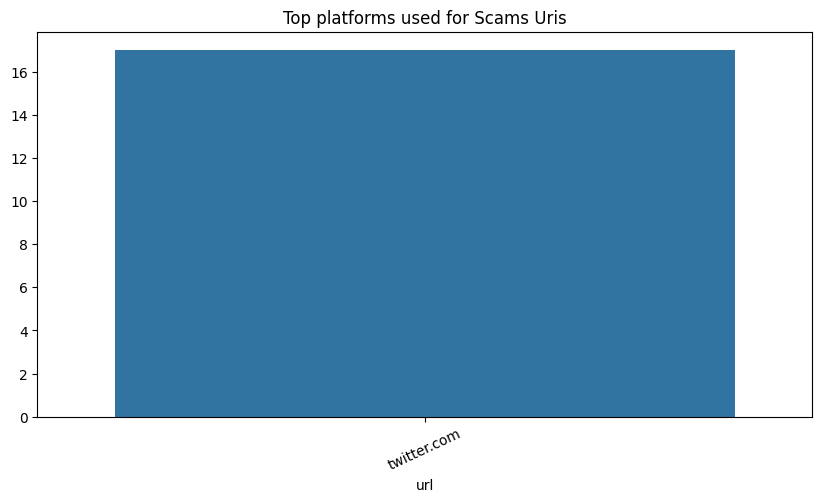

In [21]:
#uris
df_for_uris['url'] = df_for_uris['url'].apply(lambda x: urlparse(x)[1])

Top_urls_uris= df_for_uris['url'].value_counts().head(10)


plt.figure(figsize=(10,5))
sns.barplot(x=Top_urls_uris.index, y=Top_urls_uris.values)
plt.xticks(rotation=25)
plt.title("Top platforms used for Scams Uris")


Index(['Trust-Trading', 'MyEtherWallet', 'OmiseGO'], dtype='object', name='subcategory')
category       Fake ICO  Phishing  Scamming
subcategory                                
MyEtherWallet         0         1         0
OmiseGO               1         0         0
Trust-Trading         0         0        15


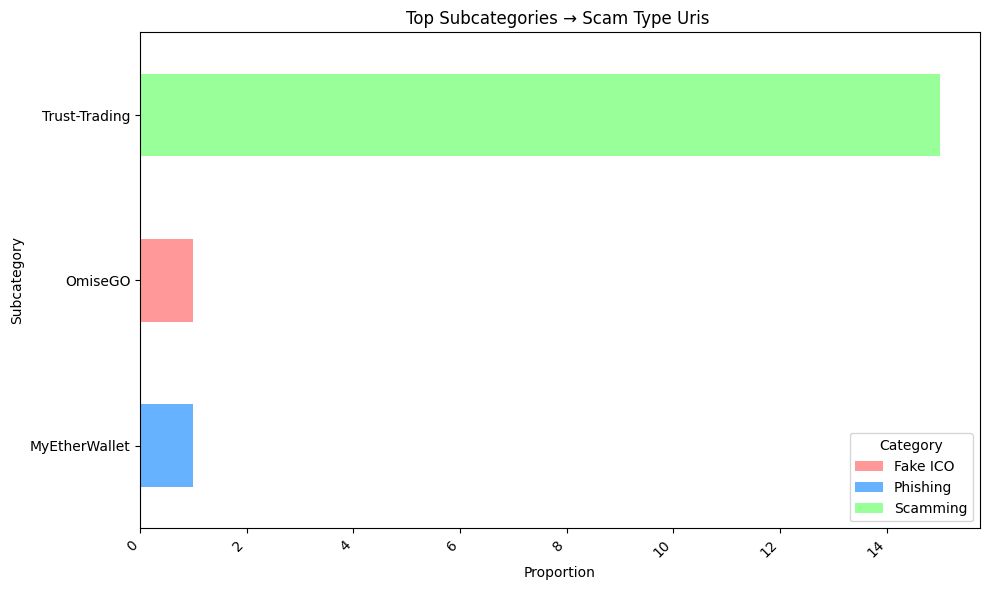

In [22]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 10 most frequent subcategories
most_subCat = df_for_uris['subcategory'].value_counts().head(10).index
print(most_subCat)
filtered_df = df_for_uris[df_for_uris['subcategory'].isin(most_subCat)]

# Create cross-tab (counts)
#https://www.geeksforgeeks.org/python/pandas-crosstab-function-in-python/
cross_tab = pd.crosstab(filtered_df['subcategory'], filtered_df['category'])
print(cross_tab)
colors = ['#FF9999', '#66B2FF', '#99FF99']
#https://codepointtech.com/visualize-data-plot-stacked-bar-charts-with-pandas/
cross_tab.plot(
    kind='barh',
    stacked=True,
    figsize=(10,6),
    color=colors
)

plt.title("Top Subcategories → Scam Type Uris ")
plt.xlabel("Proportion")
plt.ylabel("Subcategory")

plt.legend(title="Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Index(['Trust-Trading', 'MyEtherWallet', 'Exchange', 'MetaMask', 'Idex',
       'Uniswap', 'Binance', 'WalletConnect', 'Blockchain', 'Investment'],
      dtype='object', name='subcategory')
category       Malware  Phishing  Scamming
subcategory                               
Binance              0       106         2
Blockchain           0        95         0
Exchange             0        28       269
Idex                 0       163         0
Investment           0        78        14
MetaMask             8       175         4
MyEtherWallet        0      2832         1
Trust-Trading        0        63      3335
Uniswap              4       104         0
WalletConnect        0        97         1


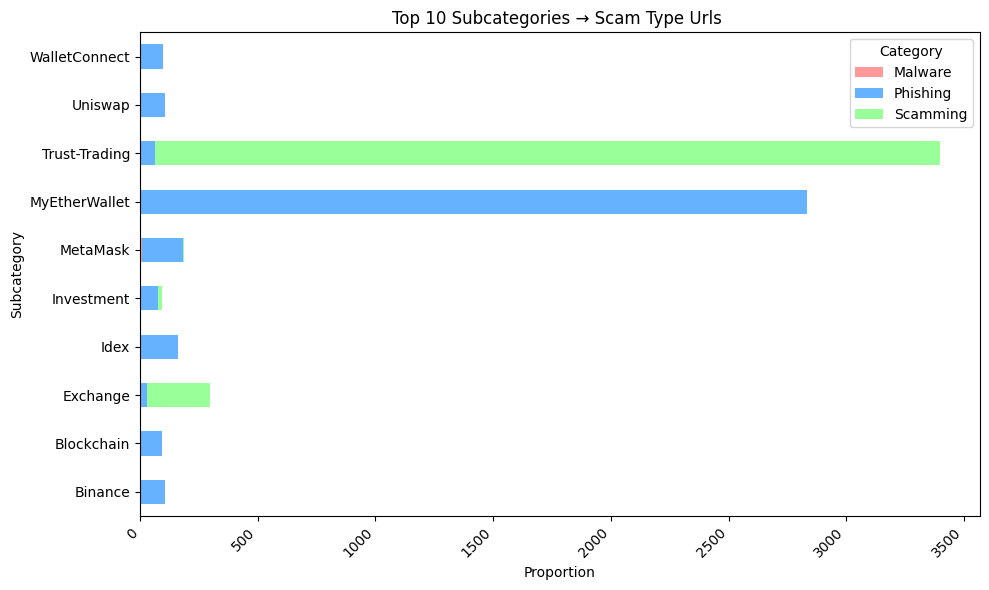

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 10 most frequent subcategories
most_subCat = df_for_urls['subcategory'].value_counts().head(10).index
print(most_subCat)
filtered_df = df_for_urls[df_for_urls['subcategory'].isin(most_subCat)]

# Create cross-tab (counts)
#https://www.geeksforgeeks.org/python/pandas-crosstab-function-in-python/
cross_tab = pd.crosstab(filtered_df['subcategory'], filtered_df['category'])
print(cross_tab)
colors = ['#FF9999', '#66B2FF', '#99FF99']
#https://codepointtech.com/visualize-data-plot-stacked-bar-charts-with-pandas/
cross_tab.plot(
    kind='barh',
    stacked=True,
    figsize=(10,6),
    color=colors
)

plt.title("Top 10 Subcategories → Scam Type Urls ")
plt.xlabel("Proportion")
plt.ylabel("Subcategory")

plt.legend(title="Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [48]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# based off previous project https://colab.research.google.com/drive/1fI2Hl5vz3XWImqNb3zNRUKpYJnydAjs6#scrollTo=jkpmmuYGbiBf

# Use data
#based on the text of the URL i want to predict the category scam , Phishing etc...
X = df_for_urls['url'] #in
y = df_for_urls['category'] #out

# splitting
#https://www.geeksforgeeks.org/machine-learning/how-to-do-train-test-split-using-sklearn-in-python/
X_train, X_test1, y_train, y_test1 = train_test_split(X, y, random_state=102,test_size=0.50,shuffle=True)
X_val, X_test2, y_val, y_test2 = train_test_split(X_test1, y_test1, random_state=102,test_size=0.50,shuffle=True)

# Convert URLs "text" to token counts
#https://www.geeksforgeeks.org/nlp/using-countvectorizer-to-extracting-features-from-text/

#first fit our vectorizer to the data ,
# so that it learns patterns
#and then use this fitted model to transform our data.
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 3),
    max_features=2000
)
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test2_vec = vectorizer.transform(X_test2)

print("Features:")
print(X_train_vec.toarray())
print("\nDocument-Term Matrix:")
print(X_val_vec.toarray())
print(X_test2_vec.toarray(),"\n")



# Initialize the Logistic Regression model with
model = LogisticRegression(class_weight='balanced', max_iter=1000,  solver='lbfgs')
# Train the model
model.fit(X_train_vec, y_train)

# Make predictions
pred = model.predict(X_test2_vec)

# Evaluate the model
print("ML Final evualation :")
print(classification_report(y_test2, pred))






Features:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Document-Term Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] 

ML Final evualation :
              precision    recall  f1-score   support

      Hacked       0.00      0.00      0.00         0
     Malware       0.04      0.19      0.07        16
    Phishing       0.95      0.56      0.70      1503
    Scamming       0.61      0.93      0.73       954

    accuracy                           0.70      2473
   macro avg       0.40      0.42      0.38      2473
weighted avg       0.81      0.70      0.71      2473



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [49]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
#Trying out naive bayes
#inspired from https://www.geeksforgeeks.org/machine-learning/comprehensive-guide-to-classification-models-in-scikit-learn/#6-naive-bayes
naive_bayesT=MultinomialNB()

#https://www.geeksforgeeks.org/machine-learning/multinomial-naive-bayes/
naive_bayesT.fit(X_train_vec,y_train)
predictionNBforTest=naive_bayesT.predict(X_test2_vec)

accuracy = accuracy_score(y_test2, predictionNBforTest)
print(f"Accuracy: {accuracy * 100:.2f}%\n")


print("Niave bayes Report:")
print(classification_report(y_test2, predictionNBforTest))


Accuracy: 78.57%

Niave bayes Report:
              precision    recall  f1-score   support

     Malware       0.00      0.00      0.00        16
    Phishing       0.77      0.92      0.84      1503
    Scamming       0.82      0.58      0.68       954

    accuracy                           0.79      2473
   macro avg       0.53      0.50      0.51      2473
weighted avg       0.79      0.79      0.77      2473



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Want i want to addd into my project

In [ ]:
!ls -R /content/drive

# Database from  FTC Consumer Sentinel Network Data Book 2024
> this can help me for for context (how big the problem is, payment trends)



In [26]:
# reading data

'''
/content/drive/MyDrive/Data_for_scam:
2024_CSN_Fraud_Reports_by_Amount_Lost.csv
2024_CSN_Fraud_Reports_by_Contact_Method.csv
2024_CSN_Fraud_Reports_by_Payment_Method.csv

'''
fraud_amountLost_DB = pd.read_csv('/content/drive/MyDrive/Data_for_scam/2024_CSN_Fraud_Reports_by_Amount_Lost.csv', header=None)
fraud_contactMet_DB = pd.read_csv('/content/drive/MyDrive/Data_for_scam/2024_CSN_Fraud_Reports_by_Contact_Method.csv', header=None)
fraud_paymentMet_DB = pd.read_csv('/content/drive/MyDrive/Data_for_scam/2024_CSN_Fraud_Reports_by_Payment_Method.csv', header=None)

In [27]:

fraud_amountLost_DB.head(60)


,0,1,2
0,Fraud Reports by Amount Lost,NaN,NaN
1,NaN,NaN,NaN
2,Number of Fraud Reports,"2,600,678",NaN
3,Reports with $ Loss,"987,520",38% of the total
4,Total $ Loss,"$12,537,194,708",NaN
5,Median $ Loss,$497,NaN
6,NaN,NaN,NaN
7,"Reported Fraud Losses in $1 - $10,000 + Range",NaN,NaN
8,Amount Lost,# of Reports,NaN
9,"$1 - $1,000","624,110",NaN


In [28]:
# cleaning up the DB

#drop useles column
fraud_amountLost_DB = fraud_amountLost_DB.drop(2, axis=1)
# Rename columns
fraud_amountLost_DB.columns = ["Amount Lost", "# of Reports"]
# Drop the rows where all elements are missing.
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html
fraud_amountLost_DB = fraud_amountLost_DB.dropna(how='any')
fraud_amountLost_DB = fraud_amountLost_DB.reset_index(drop=True)
# Use pandas styling
#drop useles rows
fraud_amountLost_DB = fraud_amountLost_DB.drop(fraud_amountLost_DB.index[:5])
fraud_amountLost_DB = fraud_amountLost_DB.drop(index=16)
fraud_amountLost_DB = fraud_amountLost_DB.reset_index(drop=True)

#Ignore for now
#cleaned_fraud_amountLost_DB= ('/content/drive/MyDrive/Data_for_scam/cleaned_fraud_amountLost_DB.csv')
#fraud_amountLost_DB.to_csv(cleaned_fraud_amountLost_DB, index=False)
#print(f"CSV saved to: {cleaned_fraud_amountLost_DB}")


In [29]:
fraud_amountLost_DB.head(60)

,Amount Lost,# of Reports
0,"$1 - $1,000","624,110"
1,"$1,001 - $2,000","97,799"
2,"$2,001 - $3,000","42,845"
3,"$3,001 - $4,000","25,466"
4,"$4,001 - $5,000","22,667"
5,"$5,001 - $6,000","12,607"
6,"$6,001 - $7,000","9,348"
7,"$7,001 - $8,000","8,770"
8,"$8,001 - $9,000","6,372"
9,"$9,001 - $10,000","12,828"


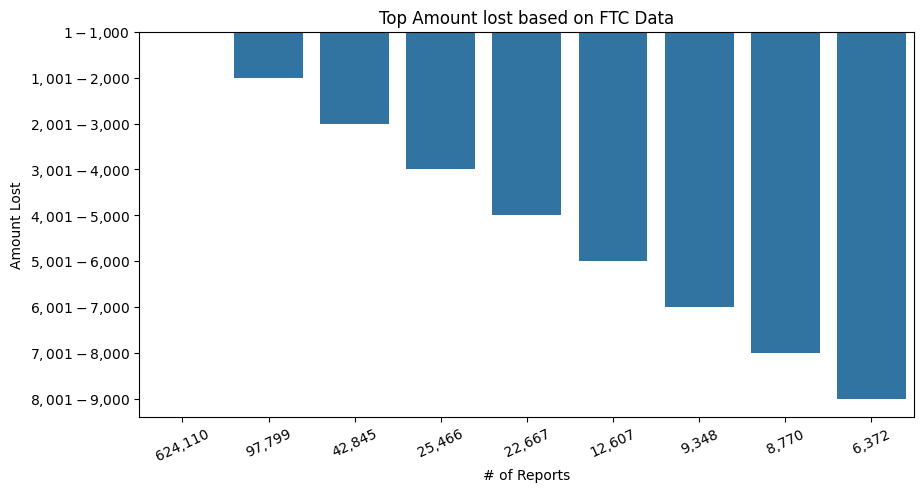

In [47]:
# want to see
#https://datascientyst.com/extract-domain-from-url-in-pandas/

Top_lost= fraud_amountLost_DB['Amount Lost'].value_counts().head(9)
Top_NumReport= fraud_amountLost_DB['# of Reports'].value_counts().head(9)
plt.figure(figsize=(10,5))
sns.barplot(x=Top_NumReport.index, y=Top_lost.index)
plt.xticks(rotation=25)
plt.title("Top Amount lost based on FTC Data")



plt.show()


In [30]:
fraud_contactMet_DB.head(60)

,0,1,2,3,4,5
0,Fraud Reports by Contact Method,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,Contact Method,# of Reports,Percentage of all Fraud Reports with a Contact...,"Of those reports, the percentage with a dollar...",Total $ Lost,Median $ Loss
3,Email,"371,651",25%,11%,$502M,$600
4,Phone call,"284,659",19%,19%,$948M,"$1,500"
5,Text,"246,784",16%,11%,$470M,"$1,000"
6,Social Media,"186,826",12%,70%,"$1,858M",$409
7,Website or Apps,"186,663",12%,68%,$976M,$200
8,Other,"148,288",10%,40%,"$1,072M",$633
9,Mail,"42,108",3%,13%,$90M,$990


In [31]:
# cleaning up the DB
fraud_contactMet_DB.columns = ["Contact Method", "# of Reports","Percentage of all Fraud Reports","the percentage with a dollar loss reported ", "Total $ Lost","Median $ Loss"]
# Drop the rows where all elements are missing.
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html
fraud_contactMet_DB = fraud_contactMet_DB.dropna(how='any')
fraud_contactMet_DB = fraud_contactMet_DB.reset_index(drop=True)
# Use pandas styling
#drop useles rows
fraud_contactMet_DB = fraud_contactMet_DB.drop(fraud_contactMet_DB.index[:1])
fraud_contactMet_DB.head(60)

'''
IGNORE for now
cleaned_fraud_contactMet_DB= ('/content/drive/MyDrive/Data_for_scam/cleaned_fraud_contactMet_DB.csv')
fraud_contactMet_DB.to_csv(cleaned_fraud_contactMet_DB, index=False)
print(f"CSV saved to: {cleaned_fraud_contactMet_DB}")
'''


'\nIGNORE for now \ncleaned_fraud_contactMet_DB= (\'/content/drive/MyDrive/Data_for_scam/cleaned_fraud_contactMet_DB.csv\')\nfraud_contactMet_DB.to_csv(cleaned_fraud_contactMet_DB, index=False)\nprint(f"CSV saved to: {cleaned_fraud_contactMet_DB}")\n'

In [32]:
fraud_contactMet_DB.head(60)

,Contact Method,# of Reports,Percentage of all Fraud Reports,the percentage with a dollar loss reported,Total $ Lost,Median $ Loss
1,Email,"371,651",25%,11%,$502M,$600
2,Phone call,"284,659",19%,19%,$948M,"$1,500"
3,Text,"246,784",16%,11%,$470M,"$1,000"
4,Social Media,"186,826",12%,70%,"$1,858M",$409
5,Website or Apps,"186,663",12%,68%,$976M,$200
6,Other,"148,288",10%,40%,"$1,072M",$633
7,Mail,"42,108",3%,13%,$90M,$990
8,Online Ad or Pop-up,"42,023",3%,62%,$246M,$180


In [33]:
fraud_paymentMet_DB.head(50)

,0,1,2
0,Fraud Reports by Payment Method,NaN,NaN
1,NaN,NaN,NaN
2,Payment Method,# of Reports,Total $ Loss
3,Credit Cards,"108,881",$275M
4,Payment App or Service,"90,571",$391M
5,Debit Card,"76,285",$180M
6,Bank Transfer or Payment,"47,336","$2,089M"
7,Cryptocurrency,"46,899","$1,417M"
8,Gift Card or Reload Card,"41,120",$212M
9,Wire Transfer,"40,448",$287M


In [34]:
# cleaning up the DB
fraud_paymentMet_DB.columns = ["Payment Method", "# of Reports","\tTotal $ Loss "]
# Drop the rows where all there is at least one element missing.
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html
fraud_paymentMet_DB = fraud_paymentMet_DB.dropna(how='any')
fraud_paymentMet_DB = fraud_paymentMet_DB.reset_index(drop=True)
fraud_paymentMet_DB.head(50)

#drop useles rows
fraud_paymentMet_DB = fraud_paymentMet_DB.drop(index=[0,11])
fraud_paymentMet_DB.head(60)

'''
IGNORE for now
cleaned_fraud_paymentMet_DB= ('/content/drive/MyDrive/Data_for_scam/cleaned_fraud_paymentMet_DB.csv')
fraud_paymentMet_DB.to_csv(cleaned_fraud_paymentMet_DB, index=False)
print(f"CSV saved to: {cleaned_fraud_paymentMet_DB}")

'''

'\nIGNORE for now\ncleaned_fraud_paymentMet_DB= (\'/content/drive/MyDrive/Data_for_scam/cleaned_fraud_paymentMet_DB.csv\')\nfraud_paymentMet_DB.to_csv(cleaned_fraud_paymentMet_DB, index=False)\nprint(f"CSV saved to: {cleaned_fraud_paymentMet_DB}")\n\n'

In [35]:
fraud_paymentMet_DB.head(50)

,Payment Method,# of Reports,\tTotal $ Loss
1,Credit Cards,"108,881",$275M
2,Payment App or Service,"90,571",$391M
3,Debit Card,"76,285",$180M
4,Bank Transfer or Payment,"47,336","$2,089M"
5,Cryptocurrency,"46,899","$1,417M"
6,Gift Card or Reload Card,"41,120",$212M
7,Wire Transfer,"40,448",$287M
8,Cash,"13,609",$308M
9,Check,"8,098",$225M
10,Money Order,"2,658",$51M
